<a href="https://colab.research.google.com/github/TiagoTBarreto/MMM_VAREJO_360/blob/main/Case_Tecnico_Uncover_MMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.0 Imports

In [ ]:
!pip install prophet -q

In [72]:
from prophet import Prophet
from google.colab import drive
from statsmodels.tsa.seasonal import STL

import os
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
pd.set_option('display.float_format', '{:.2f}'.format)

## 0.1 Funções

## 0.2 Google Drive

In [34]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
with open('/content/drive/MyDrive/.github_token', 'r') as f:
    token = f.read().strip()


os.environ['GITHUB_TOKEN'] = token

In [36]:
!git clone https://$GITHUB_TOKEN@github.com/TiagoTBarreto/MMM_VAREJO_360.git
!git config --global user.email "tiagotavaresbarreto@gmail.com"
!git config --global user.name "Tiago Barreto"

Cloning into 'MMM_VAREJO_360'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [37]:
!cd MMM_VAREJO_360/

In [48]:
!ls -l ../

total 12
drwx------ 6 root root 4096 May  5 21:51 drive
drwxr-xr-x 5 root root 4096 May  5 22:05 MMM_VAREJO_360
drwxr-xr-x 1 root root 4096 Apr 16 13:28 sample_data


## 0.3 Loading Dataset

In [55]:
df_raw = pd.read_csv('data/varejo360_weekly.csv')

# 1.0 Data Description

In [56]:
df1 = df_raw.copy()

## 1.1 Datatypes

In [58]:
df1.dtypes

,0
date,object
units_sold,int64
revenue_brl,float64
avg_price_brl,float64
tv_spend_brl,float64
google_search_spend_brl,float64
google_display_spend_brl,float64
meta_spend_brl,float64
ooh_spend_brl,float64
email_crm_sends,int64


## 1.2 Check NA

In [69]:
df1.isna().sum()

,0
date,0
units_sold,0
revenue_brl,0
avg_price_brl,0
tv_spend_brl,0
google_search_spend_brl,0
google_display_spend_brl,0
meta_spend_brl,0
ooh_spend_brl,0
email_crm_sends,0


## 1.3 Change Datatypes

In [67]:
df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')

## 1.4 Basic Descriptive Statistics

In [68]:
df1.describe()

# Over 50% of observations have zero spend in TV, OOH, and Influencer channels
# This is expected, as these channels are typically activated in campaigns rather than continuously, and their effects tend to persist over time (long adstock).

,date,units_sold,revenue_brl,avg_price_brl,tv_spend_brl,google_search_spend_brl,google_display_spend_brl,meta_spend_brl,ooh_spend_brl,email_crm_sends,influencer_spend_brl,leads_generated,website_sessions,coupons_redeemed,affiliate_commission_brl,competitor_promo_index,economic_confidence_index,is_black_friday,holiday_week
count,157,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00,157.00
mean,2023-07-03 00:00:00,20436.45,6328922.39,310.43,129612.61,146985.38,49590.79,231282.10,144702.41,186898.62,46965.16,2808.81,19655.55,345.13,61278.56,0.30,0.73,0.04,0.15
min,2022-01-03 00:00:00,14036.00,4148377.54,238.45,0.00,74129.46,21640.49,91533.29,0.00,95820.00,0.00,1788.00,16454.00,154.00,22961.69,0.01,0.43,0.00,0.00
25%,2022-10-03 00:00:00,18701.00,5811688.75,301.78,0.00,115203.25,41352.90,178568.16,0.00,144442.00,0.00,2397.00,18098.00,252.00,46146.70,0.10,0.61,0.00,0.00
50%,2023-07-03 00:00:00,19961.00,6141852.57,311.12,0.00,141246.56,47453.92,223718.36,0.00,166750.00,0.00,2672.00,19178.00,290.00,60449.71,0.24,0.73,0.00,0.00
75%,2024-04-01 00:00:00,21726.00,6675530.17,321.15,182033.20,172608.67,55600.83,266041.49,320798.11,199409.00,101250.90,3085.00,20658.00,349.00,74085.54,0.45,0.85,0.00,0.00
max,2024-12-30 00:00:00,28233.00,8704138.39,364.46,1028473.84,396689.83,102578.04,657586.11,563058.40,450054.00,251221.65,6249.00,30237.00,1633.00,126848.14,0.95,0.95,1.00,1.00
std,NaN,2487.04,742859.90,18.89,220064.29,46272.94,13209.60,75587.49,176431.88,69121.88,69470.44,580.54,2169.82,251.35,21491.97,0.24,0.15,0.19,0.36


## 2.0 Variable Classification
The selection of variables is based on theoretical reasoning and causal assumptions, rather than model performance metrics. The goal is to ensure unbiased estimation of media effects, even if it comes at the cost of predictive accuracy.

## 2.1 Choosing Target Variable (Units Sold vs. Revenue - BRL)

- Media investment data is reported in BRL, so using Revenue (BRL) as the target variable is more appropriate.
- Estimating Units Sold would introduce additional complexity, as it would require estimating the average price.
- For example, selling 1,000 units at an average price of 10 BRL results in 10,000 BRL in revenue, while selling 100 units at an average price of 100 BRL leads to the same revenue.
- Therefore, revenue provides a more direct and consistent measure aligned with media investments.

## 2.2 Choosing Independent Variables
Reference: https://towardsdatascience.com/marketing-mix-modeling-mmm-how-to-avoid-biased-channel-estimates-f9201fc3e91d/

### 2.2.1 Valid Media Variables
- TV Spend
- Google Search Spend
- Google Display Spend
- Meta Spend
- OOH Spend
- Influencer Spend
- Email CRM sends (considered as owned media activity, not paid spend)

### 2.2.2 Control Variables (Confounders)
Important variables, as they affect both revenue and media spend. Excluding them may lead the model to overestimate media effects.
- Competitor Promo Index
- Economic Confidence Index
- Is Black Friday
- Holiday Week

### 2.2.3 Excluded Variables

- units_sold: Not selected as the target variable.

- avg_price_brl: Excluded due to structural leakage, since revenue is defined as units_sold × price.

- leads_generated, website_sessions, and coupons_redeemed: Excluded as mediator (post-treatment) variables, as they are influenced by media spending and would bias the estimated causal effects of media investments.

- affiliate_commission_brl: Excluded as it is a consequence of sales and would introduce target leakage.

# 3. EDA (Exploratory Data Analysis)

In [77]:
df2 = df1.copy()

## 3.1 Time-Series Decomposition
References: https://medium.com/fifty-five-data-science/how-to-properly-handle-contextual-effects-trend-seasonality-holidays-in-marketing-mix-modeling-bd3f254d96d5
- https://rhydhamgupta.medium.com/fitting-a-base-trend-capturing-mmm-modelling-919a67adf849
- https://rhydhamgupta.medium.com/transformations-in-mmm-modelling-7fad3e4f8fe5

### 3.1.1 STL
- Upward trend in revenue, suggesting underlying business growth independent of media effects.
- The seasonal component exhibits strong and consistent patterns across years, with significant peaks. This highlights the importance of controlling for seasonality to avoid attributing these effects to media.

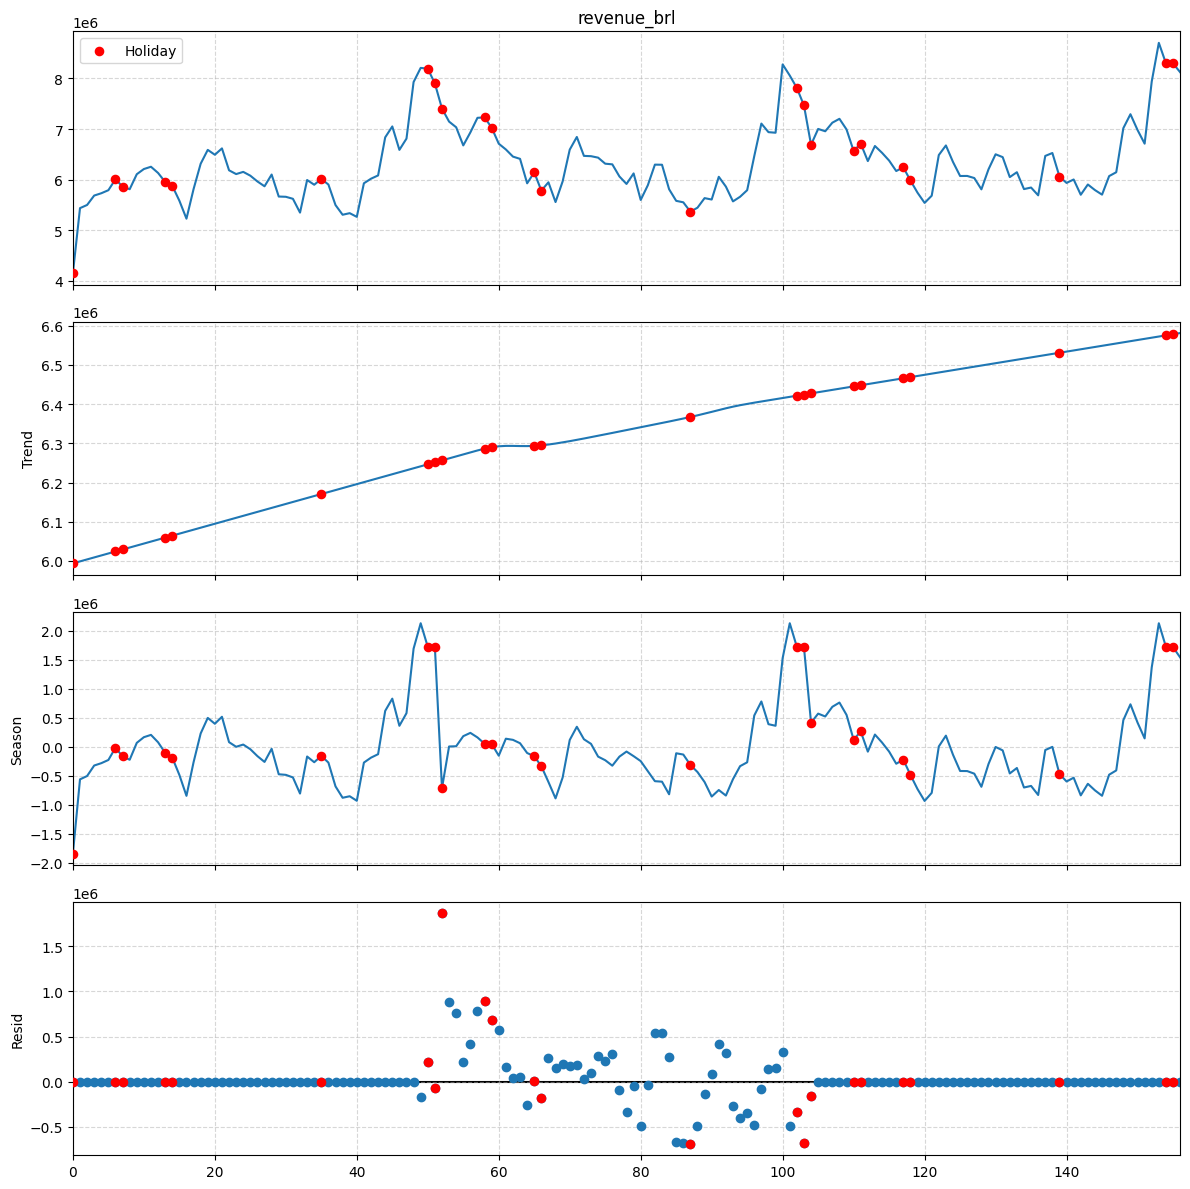

In [83]:
df_ts = df2.copy()

stl = STL(df_ts["revenue_brl"], period=52, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(12, 12)

componentes = [
    stl_result.observed,
    stl_result.trend,
    stl_result.seasonal,
    stl_result.resid
]

mask_holidays = df_ts["holiday_week"] == 1

for i, ax in enumerate(fig.get_axes()):
    x_holidays = df_ts.index[mask_holidays]
    y_holidays = componentes[i][mask_holidays]

    ax.scatter(
        x_holidays,
        y_holidays,
        color='red',
        s=35,
        zorder=5,
        label='Holiday' if i == 0 else ""
    )

    ax.grid(True, linestyle='--', alpha=0.5)
    if i == 0:
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 3.1.2 Prophet

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

df_base = df2[[
    "date",
    "revenue_brl",
    "is_black_friday",
    "holiday_week"
]].copy()

df_base = df_base.rename(columns={
    "date": "ds",
    "revenue_brl": "y"
})

df_base["ds"] = pd.to_datetime(df_base["ds"])
df_base = df_base.sort_values("ds").reset_index(drop=True)

In [86]:
baseline_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5
)

baseline_model.add_regressor("is_black_friday")
baseline_model.add_regressor("holiday_week")

baseline_model.fit(df_base)

baseline_forecast = baseline_model.predict(df_base)

In [88]:
baseline_components = baseline_forecast[[
    "ds",
    "trend",
    "yearly",
    "is_black_friday",
    "holiday_week",
    "yhat"
]].copy()

baseline_components["baseline_without_events"] = (
    baseline_components["trend"] +
    baseline_components["yearly"]
)

baseline_components["event_effect"] = (
    baseline_components["is_black_friday"] +
    baseline_components["holiday_week"]
)

baseline_components["baseline_with_events"] = (
    baseline_components["baseline_without_events"] +
    baseline_components["event_effect"]
)

baseline_components.head()

,ds,trend,yearly,is_black_friday,holiday_week,yhat,baseline_without_events,event_effect,baseline_with_events
0,2022-01-03,5275676.98,577766.23,0.00,-163113.94,5690329.27,5853443.22,-163113.94,5690329.27
1,2022-01-10,5322596.07,270926.91,0.00,0.00,5593522.99,5593522.99,0.00,5593522.99
2,2022-01-17,5369515.16,300885.07,0.00,0.00,5670400.23,5670400.23,0.00,5670400.23
3,2022-01-24,5416434.25,480930.03,0.00,0.00,5897364.29,5897364.29,0.00,5897364.29
4,2022-01-31,5463353.34,586173.40,0.00,0.00,6049526.74,6049526.74,0.00,6049526.74


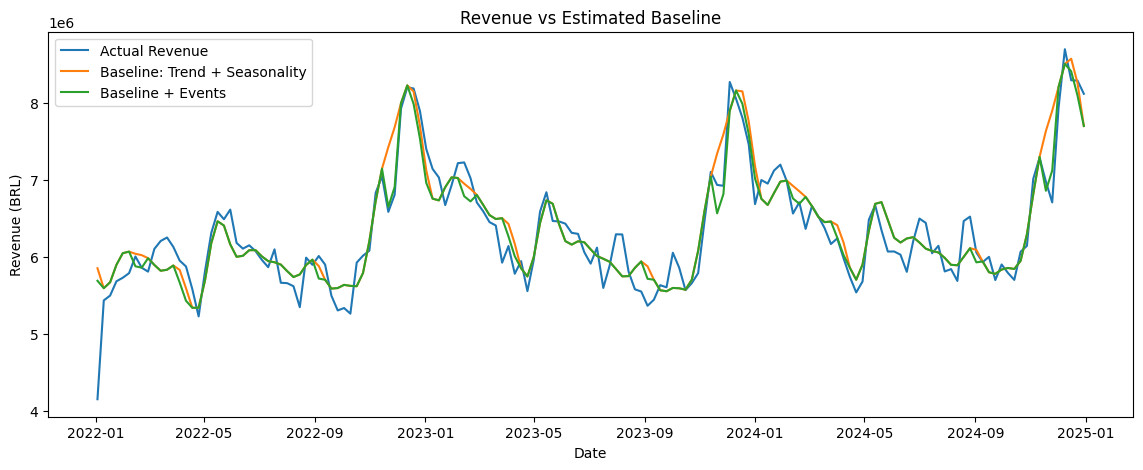

In [89]:
plt.figure(figsize=(14, 5))

plt.plot(df_base["ds"], df_base["y"], label="Actual Revenue")
plt.plot(baseline_components["ds"], baseline_components["baseline_without_events"], label="Baseline: Trend + Seasonality")
plt.plot(baseline_components["ds"], baseline_components["baseline_with_events"], label="Baseline + Events")

plt.title("Revenue vs Estimated Baseline")
plt.xlabel("Date")
plt.ylabel("Revenue (BRL)")
plt.legend()
plt.show()